# Dataset 1 — Monkeypox (Exploratory)

This notebook covers loading, filtering, and exploring the Monkeypox Misinformation dataset.

**Source:** https://www.kaggle.com/datasets/stephencrone/monkeypox  
**Year:** August 2022  
**Labels (ternary):**
- `0` → TRUE (good information)
- `1` → FALSE (misinformation)
- `9` → OTHER (personal opinion, humor, etc.)

In [5]:
import sys
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

from utils import load_human_posts

DATASET_NR = 1

## 1. Load and Filter

In [6]:
file_path = "data/datasets/monkeypox-data/monkeypox.csv"
df_raw = pd.read_csv(file_path)

print(f"Raw dataset shape: {df_raw.shape}")
print(df_raw.columns.tolist())

Raw dataset shape: (5787, 19)
['number', 'created_at', 'text', 'source', 'user is verified', 'user has url', 'user description', 'user created at', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'followers count', 'following count', 'tweet count', 'listed_count', 'user location', 'binary_class', 'ternary_class']


In [7]:
twitter_sources = [
    "Twitter for iPhone", "Twitter Web App", "Twitter for Android",
    "Twitter for iPad", "TweetDeck", "Twitter"
]
df = df_raw[df_raw['source'].isin(twitter_sources)].reset_index(drop=True)
df = df[['number', 'created_at', 'text', 'source', 'retweet_count', 'like_count',
         'binary_class', 'ternary_class']]
df = df.drop_duplicates(subset="text").reset_index(drop=True)

print(f"After filtering: {len(df)} posts")

After filtering: 4567 posts


## 2. Label Distribution

In [8]:
label_map = {0: "TRUE", 1: "FALSE", 9: "OTHER"}
df["label"] = df["ternary_class"].map(label_map)

print("Label distribution (absolute):")
print(df["label"].value_counts())
print("\nLabel distribution (relative):")
print(df["label"].value_counts(normalize=True).round(3))

Label distribution (absolute):
label
OTHER    2632
FALSE    1023
TRUE      912
Name: count, dtype: int64

Label distribution (relative):
label
OTHER    0.576
FALSE    0.224
TRUE     0.200
Name: proportion, dtype: float64


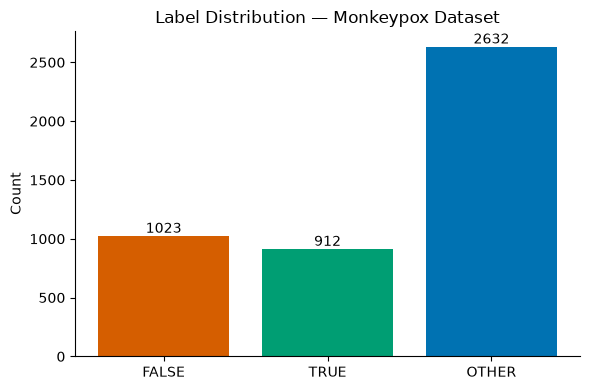

In [9]:
PALETTE = {"FALSE": "#D55E00", "TRUE": "#009E73", "OTHER": "#0072B2"}

counts = df["label"].value_counts().reindex(["FALSE", "TRUE", "OTHER"])
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[l] for l in counts.index])
ax.bar_label(bars)
ax.set_ylabel("Count")
ax.set_title("Label Distribution — Monkeypox Dataset")
sns.despine()
plt.tight_layout()
plt.show()

## 3. Text Statistics

In [10]:
df["char_len"] = df["text"].str.len()
df["word_cnt"] = df["text"].apply(lambda x: len(str(x).split()))

stats = df.groupby("label")[["char_len", "word_cnt"]].agg(["mean", "std"]).round(1)
print(stats)

      char_len       word_cnt      
          mean   std     mean   std
label                              
FALSE    179.9  99.1     28.1  14.2
OTHER    129.7  84.1     20.8  13.9
TRUE     153.9  81.5     23.9  12.7


## 4. Sample Posts per Label

In [13]:
for label in ["FALSE", "TRUE", "OTHER"]:
    print(f"\n=== {label} ===")
    sample = df[df["label"] == label]["text"].sample(3, random_state=42)
    for i, text in enumerate(sample, 1):
        print(f"  [{i}] {text}")


=== FALSE ===
  [1] No one is talking about how monkeypox is being transmitted by gays, just like HIV/AIDS.  Already memoryholed.  Good job @USMiniTru
  [2] WHO &amp; CDC WTF Happened to The Monkey Pox ?? Couldn't you frighten/ scare enough folk to implement more Ridiculous Face Nappies &amp; Lock ups - Amazing How Quickly it got forgotten about !! No Doubt you'll come up with another Deadly Plandemic to try &amp; Scare Folk. :face_with_symbols_on_mouth::face_with_symbols_on_mouth:
  [3] @FoxNews The Chinese are now working on the monkey pox virus . Gain of function again? Biden already predicted the next epidemic . There is no meaningful investigation . Finances again by US ?

=== TRUE ===
  [1] If you suspect you might have or are at risk of acquiring monkeypox, please read this no holds barred thread describing it _URL_
  [2] Monkeypox, an uncommon disease caused by infection with the monkeypox virus, is rarely fatal.
  [3] 8-9 weeks after one singular case outside Africa, Monkeypo

## 5. Via utils.load_human_posts

In [14]:
human_posts = load_human_posts(DATASET_NR)
print(f"Loaded {len(human_posts)} posts via load_human_posts(1)")
print(human_posts.dtypes)
human_posts.head()

Loaded 4567 posts via load_human_posts(1)
number           int64
created_at         str
text               str
source             str
retweet_count    int64
like_count       int64
binary_class     int64
ternary_class    int64
dtype: object


,number,created_at,text,source,retweet_count,like_count,binary_class,ternary_class
0,18,2022-07-08 10:12:04,Much of the focus on #monkeypox recently has been on how its affecting people in richer countries during this current outbreak. Dr Charles Mahzude spoke to me on #aidsmapLIVE about what we know from West Africa where moneypox is endemic about how it affects people with HIV. _URL_,Twitter Web App,2,2,0,0
1,31,2022-07-09 00:00:00,"ICYMI: The first probable case of monkeypox in West Virginia has been identified, state health officials announced Friday. _URL_",TweetDeck,2,1,0,0
2,35,2022-07-09 00:00:13,@Slinderboy @smg4official Anyone can contract monkeypox.,Twitter Web App,0,0,0,0
3,39,2022-07-09 00:00:19,Here's how you can get tested for Monkeypox if you think you've been infected :backhand_index_pointing_down: _URL_,Twitter for iPhone,6,8,0,0
4,47,2022-07-09 00:01:01,New York Post : Men likely spread monkeypox at Texas bathhouses through sex with multiple men. _URL_ via @GoogleNews,Twitter for Android,0,0,0,0
